<a href="https://colab.research.google.com/github/ty202503337/MIT-209-PROJECT/blob/main/Models/svm_marketing_campaign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Table of Contents
1. [Data Loading](#data-loading)
2. [Data Cleaning](#1.-data-cleaning)
3. [Feature Engineering & Scaling](#2.-feature-engineering-&-scaling)
4. [SVM Model Training](#3.-svm-model-training)
5. [Model Evaluation](#model-evaluation)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


<a id='data-loading'></a>
### Data Loading

In [5]:
import pandas as pd

csv_file_path = '/content/drive/MyDrive/Datasets/marketing_campaign.csv'

try:
    df = pd.read_csv(csv_file_path, sep='\t')
    print(f"Successfully loaded {csv_file_path}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully loaded /content/drive/MyDrive/Datasets/marketing_campaign.csv


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### 1. Data Cleaning
- Removing duplicates.
- Handling missing values in `Income` using the median.
- Calculating `Age` and removing outliers.
- Encoding categorical variables (`Education` and `Marital_Status`).

In [6]:
import numpy as np
from datetime import datetime

df = df.drop_duplicates()

df['Income'] = df['Income'].fillna(df['Income'].median())

current_year = datetime.now().year
df['Age'] = current_year - df['Year_Birth']
df = df[(df['Age'] > 0) & (df['Age'] < 100)]
df = df[df['Income'] < 200000]

# Categorical Encoding for Education
education_map = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_Encoded'] = df['Education'].map(education_map)

# One-Hot Encoding for Marital_Status
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital')

print(f"Cleaning complete. New shape: {df.shape}")
display(df.head())

Cleaning complete. New shape: (2236, 38)


,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Age,Education_Encoded,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,5524,1957,Graduation,58138.0,0,0,04-09-2012,58,635,88,...,69,2,False,False,False,False,True,False,False,False
1,2174,1954,Graduation,46344.0,1,1,08-03-2014,38,11,1,...,72,2,False,False,False,False,True,False,False,False
2,4141,1965,Graduation,71613.0,0,0,21-08-2013,26,426,49,...,61,2,False,False,False,False,False,True,False,False
3,6182,1984,Graduation,26646.0,1,0,10-02-2014,26,11,4,...,42,2,False,False,False,False,False,True,False,False
4,5324,1981,PhD,58293.0,1,0,19-01-2014,94,173,43,...,45,4,False,False,False,True,False,False,False,False


In [9]:
print(f'Total duplicate rows: {df.duplicated().sum()}')
print('\nMissing values per column:')
display(df.isnull().sum())

Total duplicate rows: 0

Missing values per column:


,0
ID,0
Year_Birth,0
Education,0
Income,0
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0
MntFruits,0


In [10]:
total_duplicates = df.duplicated().sum()
total_missing = df.isnull().sum().sum()

print(f'Total Duplicate Rows: {total_duplicates}')
print(f'Total Missing Values: {total_missing}')

Total Duplicate Rows: 0
Total Missing Values: 0


### 2. Feature Engineering & Scaling
- Removing PII (ID) and redundant/irrelevant features.
- Splitting the data into training and testing sets.
- Standardizing numerical features (crucial for SVM performance).

In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

irrelevant_cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue', 'Education']

cols_to_drop = [col for col in irrelevant_cols if col in df.columns] + ['Response']
X = df.drop(columns=cols_to_drop)
y = df['Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Feature engineering and standardization complete.")
print(f"Training set shape: {X_train_scaled.shape}")
display(X_train_scaled.head())

Feature engineering and standardization complete.
Training set shape: (1788, 31)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Age,Education_Encoded,Marital_Absurd,Marital_Alone,Marital_Divorced,Marital_Married,Marital_Single,Marital_Together,Marital_Widow,Marital_YOLO
0,0.243739,-0.829629,-0.940730,-1.071017,-0.113534,2.853524,1.918899,-0.060377,-0.361101,1.614932,...,0.166215,-0.457051,-0.033464,-0.040996,2.934775,-0.807772,-0.519506,-0.579934,-0.184726,-0.033464
1,-1.006680,-0.829629,-0.940730,-0.690677,-0.713544,0.238545,-0.410997,0.012307,-0.167858,1.285532,...,0.768341,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464
2,-0.669059,1.013075,-0.940730,1.141871,-0.805625,-0.515776,-0.646206,-0.478307,-0.554344,-0.690866,...,-0.607948,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,1.924906,-0.579934,-0.184726,-0.033464
3,-1.413657,1.013075,-0.940730,1.072718,-0.856121,-0.666640,-0.699460,-0.678187,-0.650965,-0.826501,...,-1.210074,1.538571,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464
4,0.202276,-0.829629,0.901576,1.176447,0.605290,-0.666640,-0.450938,-0.550991,-0.385256,-0.748995,...,0.510287,-0.457051,-0.033464,-0.040996,-0.340742,-0.807772,-0.519506,1.724336,-0.184726,-0.033464


### 3. SVM Model Training
Training the Support Vector Machine classifier.

SVM Evaluation Report:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94       381
           1       0.80      0.30      0.43        67

    accuracy                           0.88       448
   macro avg       0.84      0.64      0.69       448
weighted avg       0.88      0.88      0.86       448

ROC-AUC Score: 0.8824


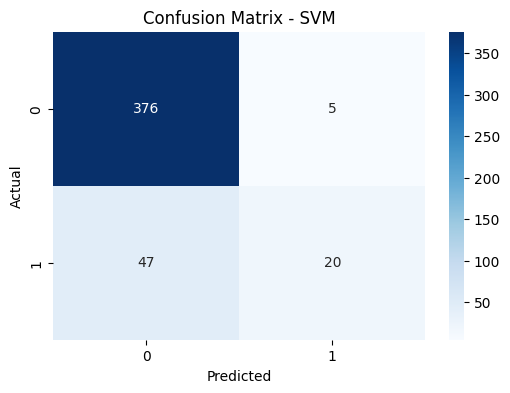

In [8]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns
import matplotlib.pyplot as plt

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM Evaluation Report:")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.4f}")

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - SVM')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

### Model Evaluation
Evaluating the model's accuracy and visualizing the classification results with a confusion matrix.

Model Accuracy Score: 0.8839


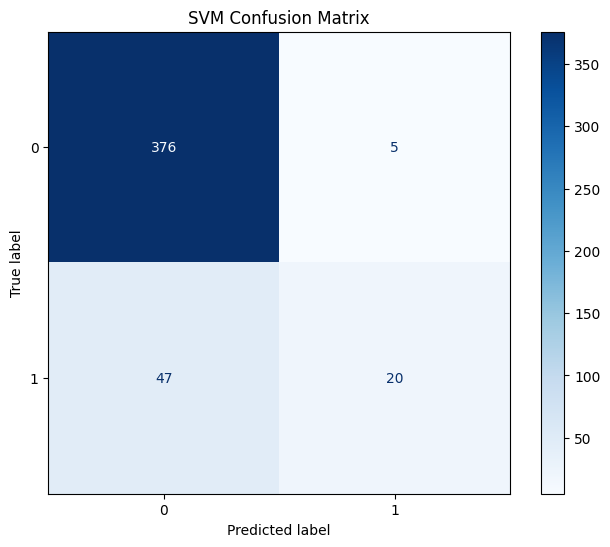

In [13]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

accuracy = accuracy_score(y_test, y_pred)
print(f'Model Accuracy Score: {accuracy:.4f}')

fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svm_model.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('SVM Confusion Matrix')
plt.show()

### 4. Exporting Model and Processed Data
Saving the trained `svm_model` and the final standardized dataset to Google Drive.

In [15]:
import pickle
import os

export_dir = '/content/drive/MyDrive/Datasets/'
if not os.path.exists(export_dir):
    os.makedirs(export_dir)

model_path = os.path.join(export_dir, 'svm_marketing_model.pkl')
with open(model_path, 'wb') as f:
    pickle.dump(svm_model, f)

final_export_df = X_test_scaled.copy()
final_export_df['Response'] = y_test.values
data_path = os.path.join(export_dir, 'svm_processed_marketing_data.csv')
final_export_df.to_csv(data_path, index=False)

print(f"Model successfully exported to: {model_path}")
print(f"Processed data successfully exported to: {data_path}")

Model successfully exported to: /content/drive/MyDrive/Datasets/svm_marketing_model.pkl
Processed data successfully exported to: /content/drive/MyDrive/Datasets/svm_processed_marketing_data.csv


### Detailed Performance Evaluation
To robustly assess the model beyond simple accuracy, we calculate Precision, Recall, and the F1-Score. These are particularly important for marketing campaigns where the 'Response' class is often imbalanced.

In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
accuracy = accuracy_score(y_test, y_pred)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
    'Value': [accuracy, precision, recall, f1, roc_auc]
})

print("SVM Model Performance Summary:")
display(metrics_df.set_index('Metric'))

SVM Model Performance Summary:


,Value
Metric,
Accuracy,0.883929
Precision,0.800000
Recall,0.298507
F1-Score,0.434783
ROC-AUC,0.882438
